# B2B Extraction Exploration

Back-to-back (.bin) → 频域校准向量 `cali_vec`。

**Pipeline:**
```
B2B .bin → _load_frames → _parse_iq → _sliding_correlate → FFT → cali_vec (U,) complex128
```

**Reference:** `src/io/b2b_extract.py`

## 1  Imports & project root

In [170]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.io.bin_read import (
    _load_frames, _parse_iq, BW_HZ, U, _S_MATCHED, _N_FFT,
    FRAME_LEN, FS_HZ,
)
from src.io.b2b_extract import extract_cali_vec, diagnose_b2b_delay
from src.paths import RAW_CALI_DIR
import src.io.bin_read as _bin_read_mod
import src.io.b2b_extract as _b2b_mod

# ── 强制所有调用走 CPU numpy FFT，避免 GPU OOM ───────────────────────────────
def _sliding_correlate_cpu(iq: np.ndarray) -> np.ndarray:
    x = iq - iq.mean(axis=1, keepdims=True)
    ext = np.tile(x, (1, 3))
    S_f = np.fft.fft(_S_MATCHED, n=_N_FFT)
    F = np.fft.fft(ext, n=_N_FFT, axis=1) * S_f
    corr = np.fft.ifft(F, axis=1)
    return (corr[:, 2 * U - 1 : 3 * U - 1] / U).astype(np.complex64)

_bin_read_mod._sliding_correlate = _sliding_correlate_cpu
_b2b_mod._sliding_correlate = _sliding_correlate_cpu

matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
%matplotlib inline

print(f"Project root : {PROJECT_ROOT}")
print(f"FRAME_LEN={FRAME_LEN}, U={U}, FS_HZ={FS_HZ/1e6:.0f} MHz, BW={BW_HZ/1e6:.0f} MHz")
print("_sliding_correlate → CPU/numpy (patched in bin_read + b2b_extract)")

Project root : /home/guo/project/chan_meas
FRAME_LEN=4132, U=1024, FS_HZ=100 MHz, BW=50 MHz
_sliding_correlate → CPU/numpy (patched in bin_read + b2b_extract)


## 2  Select B2B file

In [171]:
b2b_files = sorted(RAW_CALI_DIR.rglob("*.bin"))
print(f"RAW_CALI_DIR = {RAW_CALI_DIR}")
print(f"exists       = {RAW_CALI_DIR.exists()}")
print()
print(f"B2B .bin files ({len(b2b_files)} found):")
for i, f in enumerate(b2b_files):
    size_mb = f.stat().st_size / 1e6
    rel = f.relative_to(RAW_CALI_DIR)
    print(f"  [{i}] {rel}  ({size_mb:.1f} MB)")

RAW_CALI_DIR = /mnt/win_data/data_mea/data_save/Cali_data
exists       = True

B2B .bin files (19 found):
  [0] 20260402_cfo_mea/CFO_B2B_20260407_M13_Black01_081cable_1400M.bin  (129.7 MB)
  [1] 20260402_cfo_mea/CFO_B2B_20260407_M13_Black01_081cable_3600M.bin  (128.2 MB)
  [2] 20260402_cfo_mea/CFO_B2B_20260407_M13_Black01_081cable_4900M.bin  (131.0 MB)
  [3] 20260402_cfo_mea/CFO_B2B_20260407_M2_Black01_081cable_1400M.bin  (152.2 MB)
  [4] 20260402_cfo_mea/CFO_B2B_20260407_M2_Black01_081cable_3600M.bin  (138.9 MB)
  [5] 20260402_cfo_mea/CFO_B2B_20260407_M2_Black01_081cable_4900M.bin  (127.9 MB)
  [6] 20260402_cfo_mea/CFO_B2B_20260407_M3_Black01_081cable_1400M.bin  (153.5 MB)
  [7] 20260402_cfo_mea/CFO_B2B_20260407_M3_Black01_081cable_3600M.bin  (133.6 MB)
  [8] 20260402_cfo_mea/CFO_B2B_20260407_M3_Black01_081cable_4900M.bin  (130.2 MB)
  [9] 20260402_cfo_mea/CFO_B2B_20260407_M5_Black01_081cable_1400M.bin  (145.9 MB)
  [10] 20260402_cfo_mea/CFO_B2B_20260407_M5_Black01_081cable_3600M.bin 

## ── 选择要分析的 B2B 文件 
### 改这里：填入 b2b_files 的序号，或直接指定完整路径

In [ ]:

FILE_IDX = 4
B2B_PATH = b2b_files[FILE_IDX]

print(f"Selected: {B2B_PATH.relative_to(RAW_CALI_DIR)}")
print(f"Size    : {B2B_PATH.stat().st_size / 1e6:.1f} MB")

Selected: 20260402_cfo_mea/CFO_B2B_20260407_M2_Black01_081cable_3600M.bin
Size    : 138.9 MB


## 3  Load B2B frames → raw CIR

In [173]:
frames = _load_frames(B2B_PATH)
print(f"frames.shape = {frames.shape}  (n_frames × FRAME_LEN)")
print(f"Total bytes: {frames.nbytes / 1e6:.2f} MB")

iq = _parse_iq(frames)
del frames
print(f"iq.shape    = {iq.shape}  (n_frames × U), dtype={iq.dtype}")

cir_b2b = _sliding_correlate_cpu(iq)   # CPU numpy FFT，无 GPU 依赖
del iq
n_frames = cir_b2b.shape[0]
print(f"cir_b2b.shape = {cir_b2b.shape}  (n_frames × U), dtype={cir_b2b.dtype}")

frames.shape = (33625, 4132)  (n_frames × FRAME_LEN)
Total bytes: 138.94 MB
iq.shape    = (33625, 1024)  (n_frames × U), dtype=complex64
cir_b2b.shape = (33625, 1024)  (n_frames × U), dtype=complex64


## 4  B2B diagnostics — hardware delay

In [174]:
diag = diagnose_b2b_delay(cir_b2b)
print("B2B diagnostics (mean PDP peak):")
for k, v in diag.items():
    print(f"  {k}: {v}")

# ── 逐帧 peak delay 统计 ──────────────────────────────────────────────────────
peak_bins_per_frame = np.argmax(np.abs(cir_b2b), axis=1)          # (n_frames,)
peak_delay_per_frame_ns = peak_bins_per_frame * (1e9 / BW_HZ)     # (n_frames,)

delay_min_ns  = peak_delay_per_frame_ns.min()
delay_max_ns  = peak_delay_per_frame_ns.max()
delay_span_ns = delay_max_ns - delay_min_ns

print(f"\nPer-frame peak delay statistics ({n_frames} frames):")
print(f"  Min  : {delay_min_ns:.1f} ns  (bin {peak_bins_per_frame.min()})")
print(f"  Max  : {delay_max_ns:.1f} ns  (bin {peak_bins_per_frame.max()})")
print(f"  Span : {delay_span_ns:.1f} ns")

B2B diagnostics (mean PDP peak):
  peak_bin: 75
  peak_delay_ns: 1500.0
  peak_power_db: 56.6786994934082
  note: Peak position reflects hardware processing delay, NOT frequency offset. Do NOT use for freq correction.

Per-frame peak delay statistics (33625 frames):
  Min  : 1460.0 ns  (bin 73)
  Max  : 1520.0 ns  (bin 76)
  Span : 60.0 ns


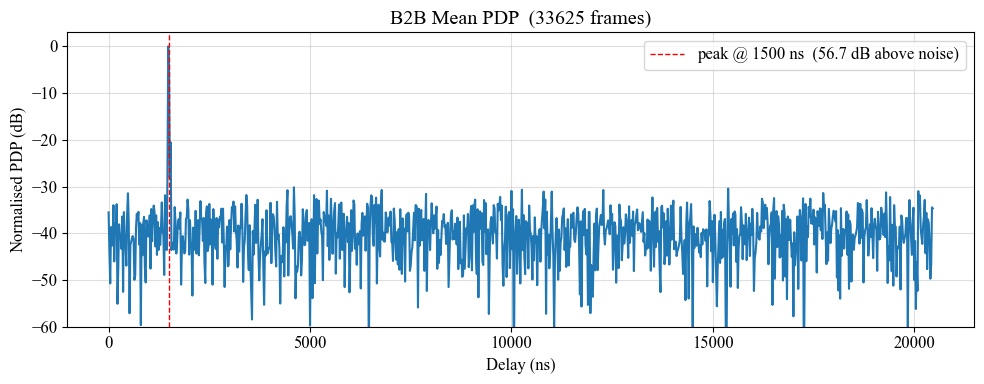

In [175]:
delay_ns = np.arange(U) / BW_HZ * 1e9

# Mean PDP — numpy/CPU
pdp = np.abs(cir_b2b[300]) ** 2
pdp_db = 10 * np.log10(pdp + 1e-30)
pdp_db -= pdp_db.max()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(delay_ns, pdp_db)
ax.axvline(diag['peak_delay_ns'], color='r', ls='--', lw=1,
           label=f"peak @ {diag['peak_delay_ns']:.0f} ns  ({diag['peak_power_db']:.1f} dB above noise)")
ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Normalised PDP (dB)')
ax.set_title(f'B2B Mean PDP  ({n_frames} frames)')
ax.set_ylim([-60, 3])
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

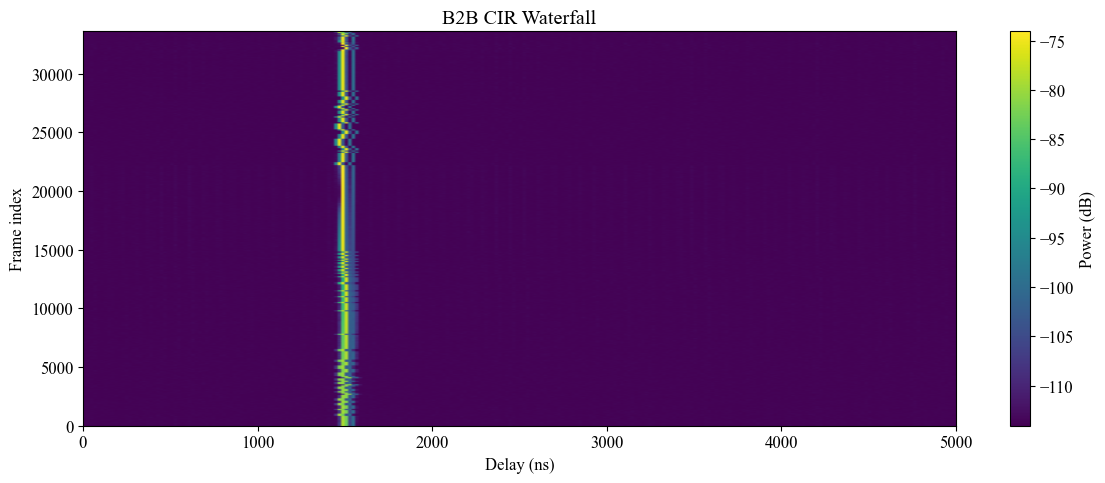

In [176]:
# B2B waterfall — numpy/CPU
cir_pwr_db = 10 * np.log10(np.abs(cir_b2b) ** 2 + 1e-30)
vmax = cir_pwr_db.max()

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    cir_pwr_db,
    aspect='auto', origin='lower', cmap='viridis',
    vmin=vmax - 40, vmax=vmax,
    extent=[delay_ns[0], delay_ns[-1], 0, n_frames],
)
fig.colorbar(im, label='Power (dB)')
ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Frame index')
ax.set_xlim(0, 5000)
ax.set_title('B2B CIR Waterfall')
fig.tight_layout()
plt.show()

## 5  Frame-to-frame phase stability

TCXO 频偏导致帧间相位漂移，验证相干平均是否可行。

Peak bin range (dynamic) : 73 ~ 76
Outliers removed         : 887 / 33624  (2.64%,  threshold = 5×MAD = 11.98 deg)
Frame period T_f         : 41.32 µs
Mean phase drift (clean) : -0.0062 rad/frame  (-0.35 deg/frame)
Std  phase drift (clean) : 0.0598 rad/frame
CFO estimate             : -23.8 Hz  (-0.024 kHz)

⚠️  This CFO is the TCXO offset between TX/RX oscillators.
   It does NOT reflect the B2B hardware delay (peak_bin position).


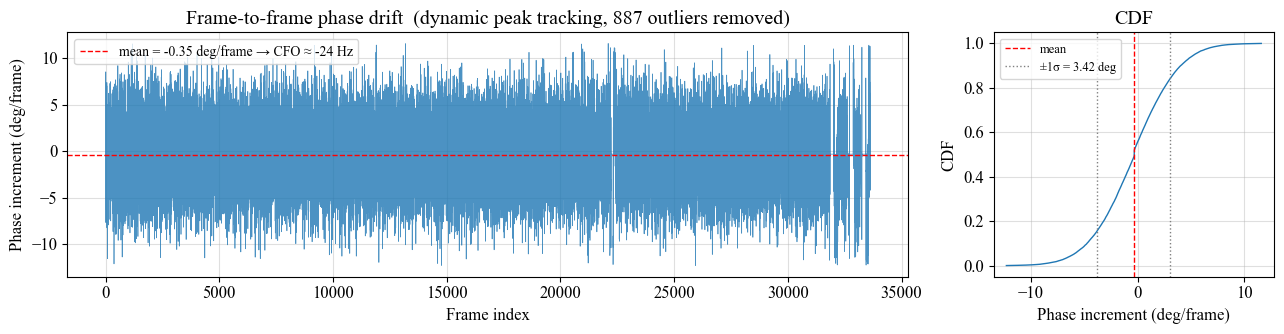

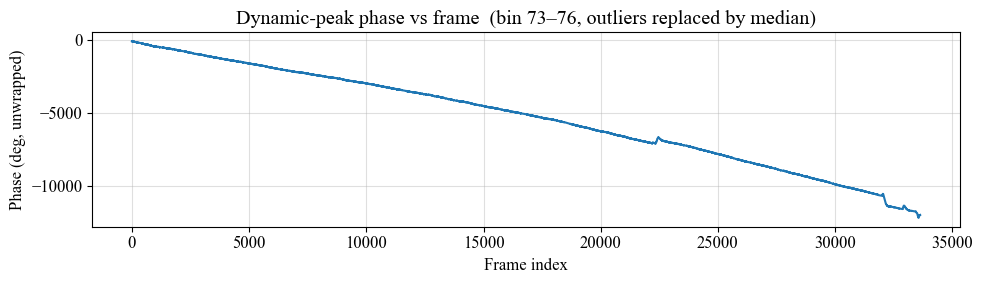

In [177]:
# ── Dynamic Peak Tracking ─────────────────────────────────────────────────────
peak_bins_per_frame  = np.argmax(np.abs(cir_b2b), axis=1)           # (n_frames,)
frame_indices        = np.arange(n_frames)
cir_at_dynamic_peak  = cir_b2b[frame_indices, peak_bins_per_frame]   # (n_frames,)

phase_at_peak         = np.angle(cir_at_dynamic_peak)
phase_unwrapped       = np.unwrap(phase_at_peak)
phase_drift_per_frame = np.diff(phase_unwrapped)                     # (n_frames-1,)

# ── Outlier removal (MAD-based) ───────────────────────────────────────────────
median_drift = np.median(phase_drift_per_frame)
mad          = np.median(np.abs(phase_drift_per_frame - median_drift))
outlier_mask = np.abs(phase_drift_per_frame - median_drift) > 5 * mad

drift_clean               = phase_drift_per_frame.copy()
drift_clean[outlier_mask] = median_drift

# 用清洗后的 drift 重建 unwrapped phase
phase_unwrapped_clean     = np.empty(n_frames)
phase_unwrapped_clean[0]  = phase_unwrapped[0]
phase_unwrapped_clean[1:] = phase_unwrapped_clean[0] + np.cumsum(drift_clean)

# ── CFO 估计 ─────────────────────────────────────────────────────────────────
T_frame_s      = FRAME_LEN / FS_HZ
mean_drift_rad = drift_clean.mean()
cfo_est_hz     = mean_drift_rad / (2 * np.pi * T_frame_s)

n_outliers = int(outlier_mask.sum())
print(f"Peak bin range (dynamic) : {peak_bins_per_frame.min()} ~ {peak_bins_per_frame.max()}")
print(f"Outliers removed         : {n_outliers} / {len(phase_drift_per_frame)}  "
      f"({100*n_outliers/len(phase_drift_per_frame):.2f}%,  threshold = 5×MAD = {np.rad2deg(5*mad):.2f} deg)")
print(f"Frame period T_f         : {T_frame_s*1e6:.2f} µs")
print(f"Mean phase drift (clean) : {mean_drift_rad:.4f} rad/frame  ({np.rad2deg(mean_drift_rad):.2f} deg/frame)")
print(f"Std  phase drift (clean) : {drift_clean.std():.4f} rad/frame")
print(f"CFO estimate             : {cfo_est_hz:.1f} Hz  ({cfo_est_hz/1e3:.3f} kHz)")
print()
print("⚠️  This CFO is the TCXO offset between TX/RX oscillators.")
print("   It does NOT reflect the B2B hardware delay (peak_bin position).")

# ── Plot 1: Frame-to-frame phase drift + CDF ─────────────────────────────────
drift_deg = np.rad2deg(drift_clean)

fig, (ax_ts, ax_cdf) = plt.subplots(1, 2, figsize=(13, 3.5),
                                     gridspec_kw={'width_ratios': [3, 1]})

# 时间序列
ax_ts.plot(drift_deg, lw=0.5, alpha=0.8)
ax_ts.axhline(np.rad2deg(mean_drift_rad), color='r', ls='--', lw=1,
              label=f'mean = {np.rad2deg(mean_drift_rad):.2f} deg/frame '
                    f'→ CFO ≈ {cfo_est_hz:.0f} Hz')
ax_ts.set_xlabel('Frame index')
ax_ts.set_ylabel('Phase increment (deg/frame)')
ax_ts.set_title(f'Frame-to-frame phase drift  '
                f'(dynamic peak tracking, {n_outliers} outliers removed)')
ax_ts.legend(fontsize=10)
ax_ts.grid(True, alpha=0.4)

# CDF
sorted_drift = np.sort(drift_deg)
cdf          = np.arange(1, len(sorted_drift) + 1) / len(sorted_drift)
ax_cdf.plot(sorted_drift, cdf, lw=1)
ax_cdf.axvline(np.rad2deg(mean_drift_rad), color='r', ls='--', lw=1,
               label=f'mean')
ax_cdf.axvline(np.rad2deg(mean_drift_rad - drift_clean.std()), color='gray', ls=':', lw=1)
ax_cdf.axvline(np.rad2deg(mean_drift_rad + drift_clean.std()), color='gray', ls=':', lw=1,
               label=f'±1σ = {np.rad2deg(drift_clean.std()):.2f} deg')
ax_cdf.set_xlabel('Phase increment (deg/frame)')
ax_cdf.set_ylabel('CDF')
ax_cdf.set_title('CDF')
ax_cdf.legend(fontsize=9)
ax_cdf.grid(True, alpha=0.4)

fig.tight_layout()
plt.show()

# ── Plot 2: Unwrapped phase (reconstructed from cleaned drift) ────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.rad2deg(phase_unwrapped_clean))
ax.set_xlabel('Frame index')
ax.set_ylabel('Phase (deg, unwrapped)')
ax.set_title(f'Dynamic-peak phase vs frame  '
             f'(bin {peak_bins_per_frame.min()}–{peak_bins_per_frame.max()}, outliers replaced by median)')
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()


## 5.5  ZC 序列多径信道仿真：两种 PDP 估计方法对比

研究 CFO 存在时两种 PDP 估计策略的性能差异：

| 方法 | 流程 | 关键效应 |
|------|------|--------|
| **结果 1**（相干平均→相关） | 15 帧 IQ 时域相干平均 → 与本地 ZC 循环相关 | 帧间 CFO 随机 → 相位无法对齐 → 相干增益损失 |
| **结果 2**（长序列→相关→平均） | 15 帧拼接成长序列 → 线性相关 → 去边缘 → 逐帧平均 | 帧内 CFO 相位旋转 → 相关峰形状失真 |

**仿真条件：**
- ZC 序列：$u=1$，$N_{ZC}=1023$，采样率 $F_s=100$ MHz（带宽 50 MHz），无 CP/ZP  
- 信道：随机 3 条多径（时延、复增益均随机），叠加 SNR = 20 dB AWGN  
- CFO：每帧独立从 Section 5 `drift_clean` 经验分布随机采样（rad/frame → Hz）

In [178]:
# ─── 仿真参数 ─────────────────────────────────────────────────────────────────
N_ZC     = 1023   # ZC 序列长度（素数）
U_ROOT   = 1      # 根序列索引 u
N_FRAMES = 15     # 连续发送帧数
N_PATHS  = 3      # 多径数量
SNR_DB   = 20     # 加性噪声 SNR (dB)

rng = np.random.default_rng(seed=42)

# ─── ZC 序列（u=1，N_ZC=1023）────────────────────────────────────────────────
n_idx = np.arange(N_ZC)
s_zc  = np.exp(-1j * np.pi * U_ROOT * n_idx * (n_idx + 1) / N_ZC)   # (N_ZC,) 恒模

print(f"ZC 序列: u={U_ROOT}, N_ZC={N_ZC},  恒模={np.allclose(np.abs(s_zc), 1.0)}")

# ─── 随机 3 条多径信道 ────────────────────────────────────────────────────────
MAX_DELAY = 50    # 最大时延（样点），对应 50 × 10 ns = 500 ns @ Fs=100 MHz
path_delays = np.sort(rng.integers(1, MAX_DELAY, N_PATHS))            # 整数时延，不含0
path_gains  = (rng.standard_normal(N_PATHS) + 1j * rng.standard_normal(N_PATHS)) / np.sqrt(2)
path_gains /= np.sqrt(np.sum(np.abs(path_gains) ** 2))                # 归一化总功率=1

h_cir = np.zeros(int(path_delays.max()) + 1, dtype=complex)
for d, g in zip(path_delays, path_gains):
    h_cir[int(d)] += g

print("\n随机 3 条多径信道:")
for i, (d, g) in enumerate(zip(path_delays, path_gains)):
    print(f"  Path {i+1}: {int(d):2d} 样点 = {int(d)*1e9/FS_HZ:5.0f} ns  "
          f"|gain|={np.abs(g):.3f}  ({20*np.log10(np.abs(g)+1e-30):.1f} dBc)")

# ─── SNR → 复噪声每分量标准差 ────────────────────────────────────────────────
# 接收端信号功率 = ZC恒模功率(=1) × 信道归一化功率(=1) = 1
noise_std = np.sqrt(1.0 / (2 * 10 ** (SNR_DB / 10)))
print(f"\nSNR={SNR_DB} dB  →  noise_std={noise_std:.4f} (per component)")

# ─── 从 drift_clean 经验分布随机采样 CFO（每帧独立）──────────────────────────
# drift_clean 单位：rad/frame，T_frame_s 均来自 Section 5
cfo_rad = rng.choice(drift_clean, size=N_FRAMES, replace=True)        # (N_FRAMES,)
cfo_hz  = cfo_rad / (2 * np.pi * T_frame_s)                           # 转换为 Hz
print(f"\n各帧 CFO: min={cfo_hz.min():.1f}  max={cfo_hz.max():.1f}  mean={cfo_hz.mean():.1f}  Hz")

ZC 序列: u=1, N_ZC=1023,  恒模=True

随机 3 条多径信道:
  Path 1:  5 样点 =    50 ns  |gain|=0.565  (-5.0 dBc)
  Path 2: 33 样点 =   330 ns  |gain|=0.357  (-8.9 dBc)
  Path 3: 38 样点 =   380 ns  |gain|=0.744  (-2.6 dBc)

SNR=20 dB  →  noise_std=0.0707 (per component)

各帧 CFO: min=-325.0  max=454.6  mean=31.3  Hz


In [179]:
# ─── 生成 15 帧 IQ（信道线性卷积 + AWGN + 帧内 CFO 旋转）────────────────────
t_samp    = np.arange(N_ZC)                              # 帧内样点索引 0…1022
iq_frames = np.empty((N_FRAMES, N_ZC), dtype=complex)

for k in range(N_FRAMES):
    # 1. 线性卷积，取前 N_ZC 点（信道长度 ≪ N_ZC，截断边缘可忽略）
    rx = np.convolve(s_zc, h_cir)[:N_ZC]

    # 2. AWGN（复高斯，每分量 std = noise_std）
    noise = noise_std * (rng.standard_normal(N_ZC) + 1j * rng.standard_normal(N_ZC))
    rx   += noise

    # 3. 帧内 CFO 相位旋转（每帧独立 CFO）
    rx   *= np.exp(1j * 2 * np.pi * cfo_hz[k] * t_samp / FS_HZ)

    iq_frames[k] = rx

print(f"iq_frames.shape = {iq_frames.shape},  dtype = {iq_frames.dtype}")
print(f"各帧均值功率    = {np.mean(np.abs(iq_frames)**2):.3f}  (理论 ≈ 1 + noise_var)")

iq_frames.shape = (15, 1023),  dtype = complex128
各帧均值功率    = 0.996  (理论 ≈ 1 + noise_var)


In [180]:
# ─── 结果 1：相干平均 → 循环相关 ─────────────────────────────────────────────
iq_avg  = iq_frames.mean(axis=0)                         # (N_ZC,)

# 频域循环互相关：C = IFFT( FFT(iq_avg) · FFT(s_zc)* )
Corr1_f = np.fft.fft(iq_avg) * np.conj(np.fft.fft(s_zc))
corr1   = np.fft.ifft(Corr1_f)                           # (N_ZC,)
pdp1    = np.abs(corr1) ** 2
pdp1_db = 10 * np.log10(pdp1 + 1e-30)
pdp1_db -= pdp1_db.max()

print(f"结果1  iq_avg {iq_avg.shape} → 循环相关 → corr1 {corr1.shape}")
print(f"  PDP1 峰值: 第 {np.argmax(pdp1)} 样点  ({np.argmax(pdp1)*1e9/FS_HZ:.0f} ns)")

# ─── 结果 2：长序列线性相关 → 去边缘 → 逐帧平均 ──────────────────────────────
iq_long = iq_frames.ravel()                              # (N_FRAMES × N_ZC,) = (15345,)

# FFT 加速线性互相关（等价 np.correlate mode='full'，快约 100×）
N_lin  = len(iq_long) + N_ZC - 1                         # 16 × N_ZC − 1 = 16 367
N_fft2 = int(2 ** np.ceil(np.log2(N_lin)))               # 最近 2^k
Corr2_f    = np.fft.fft(iq_long, n=N_fft2) * np.conj(np.fft.fft(s_zc, n=N_fft2))
corr2_full = np.fft.ifft(Corr2_f)[:N_lin]               # (16 367,)

print(f"\n结果2  iq_long {iq_long.shape} → 线性相关 → corr2_full {corr2_full.shape}")
assert corr2_full.shape[0] == 16 * N_ZC - 1, "长度校验失败"

# 去掉头部 N_ZC 点（第1帧边缘不完整）和尾部 N_ZC−1 点（第15帧边缘不完整）
# 剩余 14 × N_ZC 点，reshape → (14, N_ZC) → 逐帧平均
corr2_trim = corr2_full[N_ZC : N_ZC + 14 * N_ZC]        # (14 × 1023,)
corr2_mat  = corr2_trim.reshape(14, N_ZC)                # (14, 1023)
corr2_avg  = corr2_mat.mean(axis=0)                      # (1023,)

pdp2    = np.abs(corr2_avg) ** 2
pdp2_db = 10 * np.log10(pdp2 + 1e-30)
pdp2_db -= pdp2_db.max()

print(f"  去边缘 → reshape {corr2_mat.shape} → avg → corr2_avg {corr2_avg.shape}")
print(f"  PDP2 峰值: 第 {np.argmax(pdp2)} 样点  ({np.argmax(pdp2)*1e9/FS_HZ:.0f} ns)")

结果1  iq_avg (1023,) → 循环相关 → corr1 (1023,)
  PDP1 峰值: 第 38 样点  (380 ns)

结果2  iq_long (15345,) → 线性相关 → corr2_full (16367,)
  去边缘 → reshape (14, 1023) → avg → corr2_avg (1023,)
  PDP2 峰值: 第 38 样点  (380 ns)


/tmp/ipykernel_3846700/4095169072.py:30: UserWarning: Glyph 20272 (\N{CJK UNIFIED IDEOGRAPH-4F30}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_3846700/4095169072.py:30: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_3846700/4095169072.py:30: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_3846700/4095169072.py:30: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_3846700/4095169072.py:30: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAPH-5F84}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_3846700/4095169072.py:30: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) Times New Roman.
  fig.tight_layout()
/tmp/ipykernel_3846700/4095169072.py:30: UserWarning

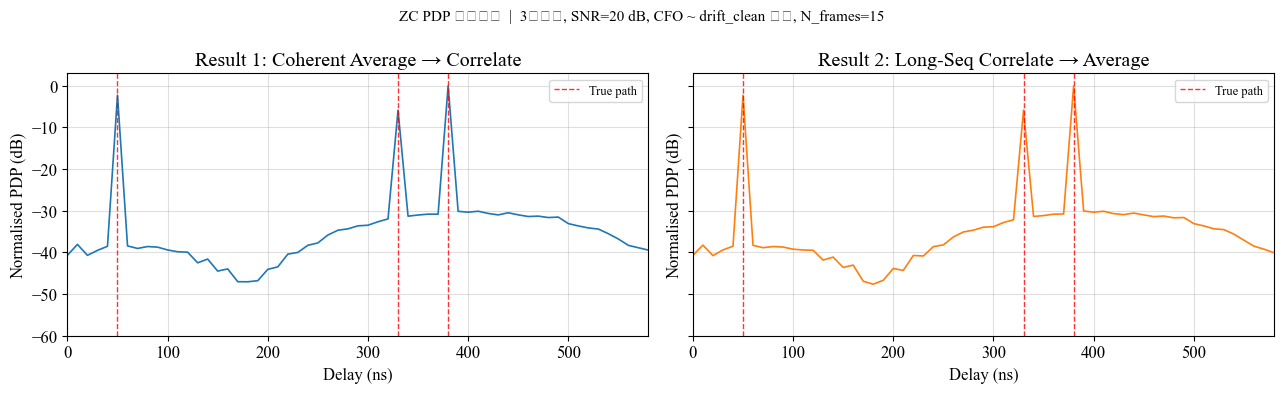

In [181]:
# ─── 对比绘图 ────────────────────────────────────────────────────────────────
delay_axis_ns = np.arange(N_ZC) * 1e9 / FS_HZ          # 时延轴 (ns)，分辨率 = 1/Fs

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, pdp_db, title, color in zip(
    axes,
    [pdp1_db, pdp2_db],
    ['Result 1: Coherent Average → Correlate',
     'Result 2: Long-Seq Correlate → Average'],
    ['C0', 'C1'],
):
    ax.plot(delay_axis_ns, pdp_db, lw=1.2, color=color)
    for d in path_delays:
        ax.axvline(d * 1e9 / FS_HZ, color='r', ls='--', lw=1, alpha=0.8,
                   label='True path' if d == path_delays[0] else None)
    ax.set_xlabel('Delay (ns)')
    ax.set_ylabel('Normalised PDP (dB)')
    ax.set_title(title)
    ax.set_xlim([0, (path_delays.max() + 20) * 1e9 / FS_HZ])
    ax.set_ylim([-60, 3])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

fig.suptitle(
    f'ZC PDP 估计对比  |  3径信道, SNR={SNR_DB} dB, '
    f'CFO ~ drift_clean 分布, N_frames={N_FRAMES}',
    fontsize=11,
)
fig.tight_layout()
plt.show()

## 6  Extract calibration vector

对比三种提取策略：
- **n_avg=1**：单帧，无偏但噪声大
- **mag_avg=True, n_avg=N**：幅度平均 + 帧0相位（推荐）
- **mag_avg=False, n_avg=N**：相干平均（TCXO漂移大时失真）

In [182]:
import warnings

N_AVG = min(50, n_frames)

cali_single   = extract_cali_vec(B2B_PATH, n_avg=1)
cali_mag_avg  = extract_cali_vec(B2B_PATH, n_avg=N_AVG, mag_avg=True)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)
    cali_coherent = extract_cali_vec(B2B_PATH, n_avg=N_AVG, mag_avg=False)

print(f"cali_vec shape: {cali_mag_avg.shape}, dtype: {cali_mag_avg.dtype}")
print(f"N_AVG = {N_AVG}")

cali_vec shape: (1024,), dtype: complex128
N_AVG = 50


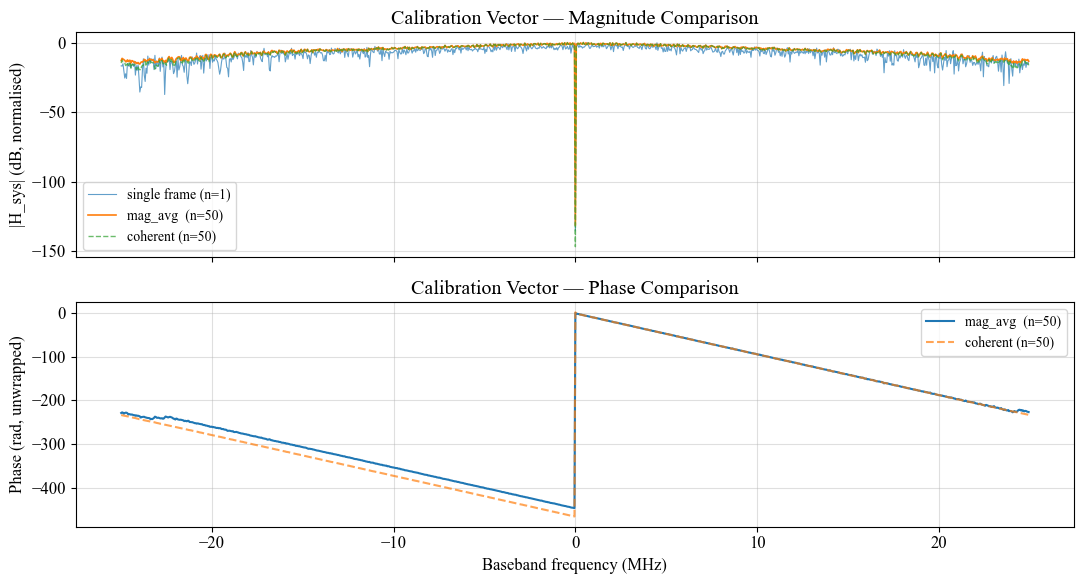

In [183]:
freqs_mhz = np.fft.fftfreq(U, d=1.0 / BW_HZ) / 1e6
_s = np.argsort(freqs_mhz)   # sort for clean plot

def to_db(v):
    m = 20 * np.log10(np.abs(v) + 1e-30)
    return m - m.max()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(freqs_mhz[_s], to_db(cali_single)[_s],   lw=0.8, label='single frame (n=1)', alpha=0.7)
axes[0].plot(freqs_mhz[_s], to_db(cali_mag_avg)[_s],  lw=1.2, label=f'mag_avg  (n={N_AVG})')
axes[0].plot(freqs_mhz[_s], to_db(cali_coherent)[_s], lw=1.0, label=f'coherent (n={N_AVG})', ls='--', alpha=0.7)
axes[0].set_ylabel('|H_sys| (dB, normalised)')
axes[0].set_title('Calibration Vector — Magnitude Comparison')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)

axes[1].plot(freqs_mhz[_s], np.unwrap(np.angle(cali_mag_avg))[_s],  label=f'mag_avg  (n={N_AVG})')
axes[1].plot(freqs_mhz[_s], np.unwrap(np.angle(cali_coherent))[_s], label=f'coherent (n={N_AVG})', ls='--', alpha=0.7)
axes[1].set_xlabel('Baseband frequency (MHz)')
axes[1].set_ylabel('Phase (rad, unwrapped)')
axes[1].set_title('Calibration Vector — Phase Comparison')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)

fig.tight_layout()
plt.show()

## 7  Noise floor vs N_AVG (mag_avg=True)

评估幅度平均数 `n_avg` 对校准向量噪声的影响。

  n_avg=   1  CV(|H|) = -6.7 dB
  n_avg=   5  CV(|H|) = -8.1 dB
  n_avg=  10  CV(|H|) = -8.2 dB
  n_avg=  20  CV(|H|) = -8.2 dB
  n_avg=  50  CV(|H|) = -8.2 dB
  n_avg= 100  CV(|H|) = -8.2 dB


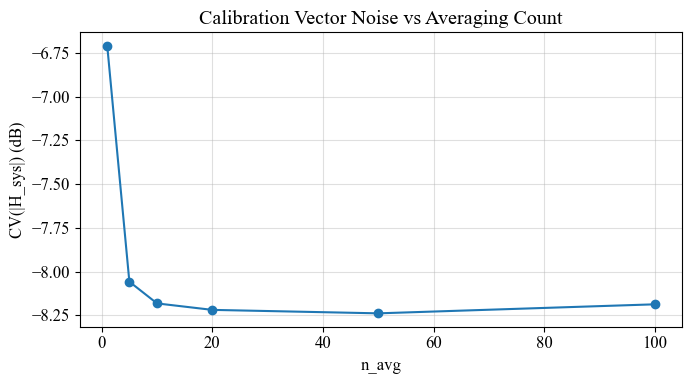

In [184]:
n_avg_list = [1, 5, 10, 20, 50, min(100, n_frames)]
noise_floor_db = []

for n in n_avg_list:
    cv = extract_cali_vec(B2B_PATH, n_avg=n, mag_avg=(n > 1))
    mag = np.abs(cv)
    noise = np.std(mag) / mag.mean()   # coefficient of variation
    noise_floor_db.append(20 * np.log10(noise + 1e-30))
    print(f"  n_avg={n:4d}  CV(|H|) = {20*np.log10(noise+1e-30):.1f} dB")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_avg_list, noise_floor_db, 'o-')
ax.set_xlabel('n_avg')
ax.set_ylabel('CV(|H_sys|) (dB)')
ax.set_title('Calibration Vector Noise vs Averaging Count')
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

## 8  Final cali_vec summary

In [185]:
# Use mag_avg as the production cali_vec
cali_vec = cali_mag_avg

mag_db = 20 * np.log10(np.abs(cali_vec) + 1e-30)
print("=== cali_vec summary ===")
print(f"  shape   : {cali_vec.shape}")
print(f"  dtype   : {cali_vec.dtype}")
print(f"  |H| max : {mag_db.max():.2f} dB")
print(f"  |H| min : {mag_db.min():.2f} dB")
print(f"  |H| std : {mag_db.std():.2f} dB")
print(f"  n_avg   : {N_AVG} (mag_avg=True)")
print(f"\nReady for apply_fr_calibration() in cali_explore.ipynb")

=== cali_vec summary ===
  shape   : (1024,)
  dtype   : complex128
  |H| max : -72.68 dB
  |H| min : -204.00 dB
  |H| std : 5.47 dB
  n_avg   : 50 (mag_avg=True)

Ready for apply_fr_calibration() in cali_explore.ipynb
